# Notebook 9 — Categorical Analysis
### Telecom Customer Churn Dataset

**Categorical analysis** is a statistical method used to study qualitative data that is divided into groups or categories rather than measured with numbers

We'll also look at relationships between the key categorical predictors and `churn` using
cross-tabulations, stacked bar charts, and chi-square tests of independence.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
df = pd.read_csv('telecom_customer_churn.csv')
cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service',
            'internet_service', 'contract', 'paperless_billing', 'payment_method']
target = 'churn'
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


## 1. Unique Categories & Cardinality

**Cardinality** = the number of distinct categories a variable has.
- **Low cardinality**: few distinct values (e.g., a Yes/No flag) — easy to one-hot encode, easy to
  visualize.
- **High cardinality**: many distinct values (e.g., customer IDs, ZIP codes) — can cause sparse
  encodings and overfitting if used naively in modeling.

Let's check the number of unique values per categorical column.

In [2]:
cardinality = pd.DataFrame({
    'n_unique': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}, index=cat_cols).sort_values('n_unique', ascending=False)

cardinality

,n_unique,n_missing
gender,6,0
partner,6,0
paperless_billing,6,0
payment_method,4,15
contract,3,0
internet_service,3,20
phone_service,2,0
senior_citizen,2,0
dependents,2,0


**Observation:** every column here is technically **low cardinality** (2–4 *intended*
categories) for a well-formed dataset. However, the `nunique()` counts for `gender`, `partner`, and
`paperless_billing` come out **higher than expected** (more than 2 distinct values for what should
be a binary Yes/No or Male/Female field) — a strong signal of **inconsistent category labels**
(casing/typo issues), not genuine extra categories. We investigate this next.

## 2. Category Frequencies & Distribution — Raw (Uncleaned)

Let's look at the raw value counts before cleaning anything, since this is where labeling
inconsistencies become obvious.

In [3]:
for col in ['gender', 'partner', 'paperless_billing']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- gender ---
gender
Female    498
Male      490
female      9
F           7
M           7
male        4
Name: count, dtype: int64

--- partner ---
partner
No     501
Yes    492
yes      7
Y        7
N        5
no       3
Name: count, dtype: int64

--- paperless_billing ---
paperless_billing
Yes    604
No     386
N        8
yes      7
Y        5
no       5
Name: count, dtype: int64



**Finding — inconsistent labeling (a data-quality issue, not real extra categories):**
- `gender`: `'Male'`, `'male'`, `'M'` all mean the same thing; likewise `'Female'`, `'female'`, `'F'`.
- `partner`: `'Yes'`, `'yes'`, `'Y'` and `'No'`, `'no'`, `'N'` are duplicated by casing/abbreviation.
- `paperless_billing`: same Yes/No casing and abbreviation issue.

These aren't **rare categories** in the statistical sense — they're the **same category encoded
inconsistently**, which will silently fragment counts and confuse any groupby/model if left as-is.
We standardize them below.

In [4]:
def standardize_yes_no(series):
    mapping = {
        'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No',
        'Yes': 'Yes', 'No': 'No'
    }
    return series.str.strip().str.lower().map(
        {'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No'}
    )

def standardize_gender(series):
    return series.str.strip().str.lower().map(
        {'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'}
    )

df['gender_clean'] = standardize_gender(df['gender'])
df['partner_clean'] = standardize_yes_no(df['partner'])
df['paperless_billing_clean'] = standardize_yes_no(df['paperless_billing'])

for col in ['gender_clean', 'partner_clean', 'paperless_billing_clean']:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- gender_clean ---
gender_clean
Female    514
Male      501
Name: count, dtype: int64

--- partner_clean ---
partner_clean
No     509
Yes    506
Name: count, dtype: int64

--- paperless_billing_clean ---
paperless_billing_clean
Yes    616
No     399
Name: count, dtype: int64



After standardizing casing/abbreviations, each of these columns cleanly resolves to its
**true low cardinality** (2 categories), confirming the "extra categories" seen earlier were a
labeling artifact rather than genuine rare categories.

For the rest of this notebook, we use the cleaned versions (`gender_clean`, `partner_clean`,
`paperless_billing_clean`) alongside the columns that were already clean.

In [5]:
clean_cat_cols = ['gender_clean', 'senior_citizen', 'partner_clean', 'dependents',
                   'phone_service', 'internet_service', 'contract',
                   'paperless_billing_clean', 'payment_method']

## 3. Category Frequency Bar Charts

Visualizing the frequency of each category makes **imbalance** and **rare categories** easy to
spot at a glance.

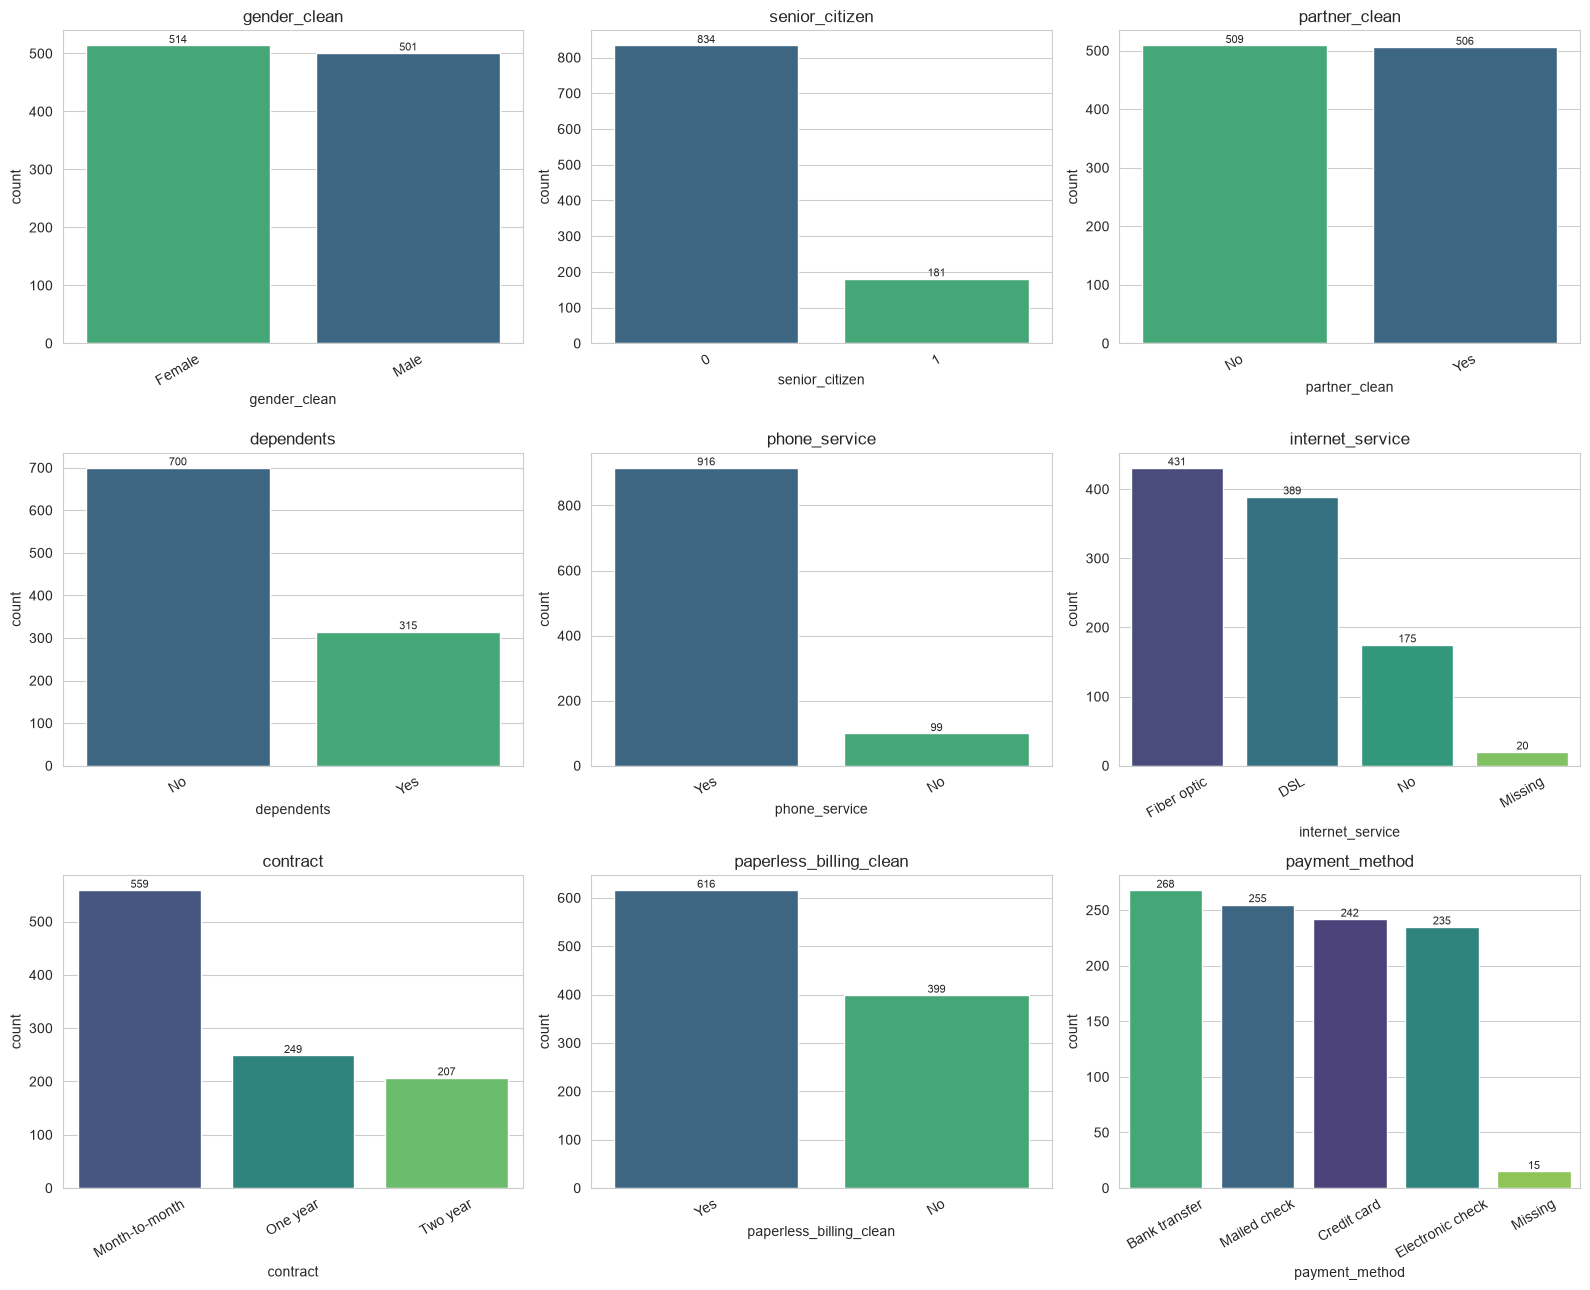

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for ax, col in zip(axes, clean_cat_cols):
    plot_series = df[col].astype('string').fillna('Missing')
    order = plot_series.value_counts().index
    sns.countplot(x=plot_series, order=order, ax=ax, palette='viridis', hue=plot_series, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Reading the charts:**
- `gender_clean`, `partner_clean` — near **50/50 splits**, well balanced.
- `senior_citizen` — clearly **imbalanced**: most customers are not senior citizens.
- `dependents`, `phone_service`, `paperless_billing_clean` — moderate imbalance (roughly 2:1 or
  9:1 splits).
- `internet_service`, `contract`, `payment_method` — 3–4 categories each, none of which is
  vanishingly rare, but `internet_service = 'No'` and `contract = 'Two year'` are the smaller
  groups within their respective columns.


## 4. Rare Categories & Category Imbalance

A common rule of thumb: a category is **"rare"** if it makes up less than ~5% of the total
observations. Rare categories can cause problems for modeling (unstable estimates, one-hot columns
that are almost always zero) and deserve a decision: group them into an "Other" bucket, or leave
as-is if they're meaningful.

In [7]:
def category_proportions(col):
    counts = df[col].value_counts(dropna=False)
    props = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({'count': counts, 'pct': props})
rare_threshold = 5.0
print(f'Flagging categories under {rare_threshold}% of total as RARE\n')
for col in clean_cat_cols:
    prop_df = category_proportions(col)
    rare = prop_df[prop_df['pct'] < rare_threshold]
    if len(rare) > 0:
        print(f'--- {col} ---')
        print(prop_df)
        print(f'  -> RARE categories: {list(rare.index)}\n')

Flagging categories under 5.0% of total as RARE

--- internet_service ---
                  count    pct
internet_service              
Fiber optic         431  42.46
DSL                 389  38.33
No                  175  17.24
NaN                  20   1.97
  -> RARE categories: [nan]

--- payment_method ---
                  count    pct
payment_method                
Bank transfer       268  26.40
Mailed check        255  25.12
Credit card         242  23.84
Electronic check    235  23.15
NaN                  15   1.48
  -> RARE categories: [nan]



**Findings:**
- Under our 5% threshold, none of the *cleaned* categorical variables have a truly rare category —
  the smallest legitimate group (e.g., `contract = 'Two year'` at ~20%, `internet_service = 'No'`
  at ~17%) is still a substantial, meaningful segment, not statistical noise.
- The **missing values** in `internet_service` (~2%) and `payment_method` (~1.5%) are technically
  "rare" by count, but they represent **missingness**, not a real category — these should be
  handled via imputation or an explicit "Unknown" category, not treated like a rare class to merge
  away.
- **Decision:** No categories require merging into "Other" here — cardinality is already low and
  every category is business-meaningful (contract length, service type, payment method all matter
  for churn analysis).


## 5. Category Imbalance — Focus on the Target Variable (`churn`)

Since `churn` is our target variable, its balance matters a lot for modeling choices (e.g.,
whether we need class-weighting or resampling techniques later).

churn
No     697
Yes    318
Name: count, dtype: int64
churn
No     68.67
Yes    31.33
Name: count, dtype: float64


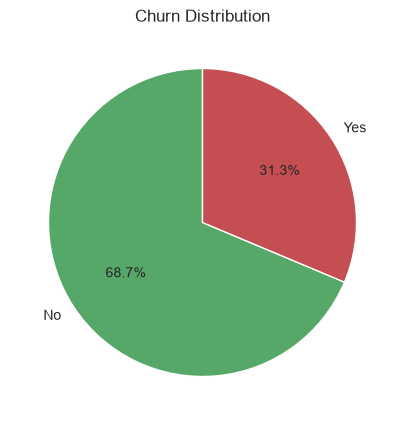

In [9]:
churn_counts = df['churn'].value_counts()
churn_pct = (churn_counts / churn_counts.sum() * 100).round(2)
print(churn_counts)
print(churn_pct)
plt.figure(figsize=(5, 5))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=['#55A868', '#C44E52'], startangle=90)
plt.title('Churn Distribution')
plt.show()

**Finding:** `churn` is **imbalanced** — roughly 31% "Yes" vs. 69% "No". This is a moderate
imbalance (not extreme, like 1% vs 99%), but it's still worth accounting for later: plain accuracy
would be a misleading metric for a churn model, and techniques like class weighting, stratified
sampling, or resampling (SMOTE, etc.) may be worth considering during modeling.

## 6. Relationships Between Categorical Variables and `churn`

For each key categorical predictor, we build a cross-tabulation against `churn`, visualize it as a
stacked/grouped bar chart, and run a **Chi-Square test of independence** to check whether the
relationship is statistically significant.

- **H₀:** the categorical variable and `churn` are independent (no relationship)
- **H₁:** there is an association between the variable and `churn`
- If **p-value < 0.05**, we reject H₀ → there **is** a significant relationship.

In [10]:
def chi_square_test(col, target='churn'):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return chi2, p, dof, contingency

chi_results = []
for col in clean_cat_cols:
    chi2, p, dof, _ = chi_square_test(col)
    chi_results.append({'feature': col, 'chi2_statistic': round(chi2, 2),
                         'p_value': round(p, 5), 'degrees_of_freedom': dof,
                         'significant_at_0.05': p < 0.05})

chi_df = pd.DataFrame(chi_results).sort_values('p_value')
chi_df

,feature,chi2_statistic,p_value,degrees_of_freedom,significant_at_0.05
6,contract,112.22,0.00000,2,True
4,phone_service,5.72,0.01680,1,True
3,dependents,2.22,0.13610,1,False
2,partner_clean,1.84,0.17462,1,False
1,senior_citizen,0.10,0.75131,1,False
8,payment_method,1.15,0.76434,3,False
5,internet_service,0.31,0.85768,2,False
0,gender_clean,0.01,0.94212,1,False
7,paperless_billing_clean,0.00,1.00000,1,False


This table ranks the categorical features by how strongly (and significantly) they're
associated with churn — the smaller the p-value, the stronger the evidence of a real relationship.
Let's visualize the top relationships.

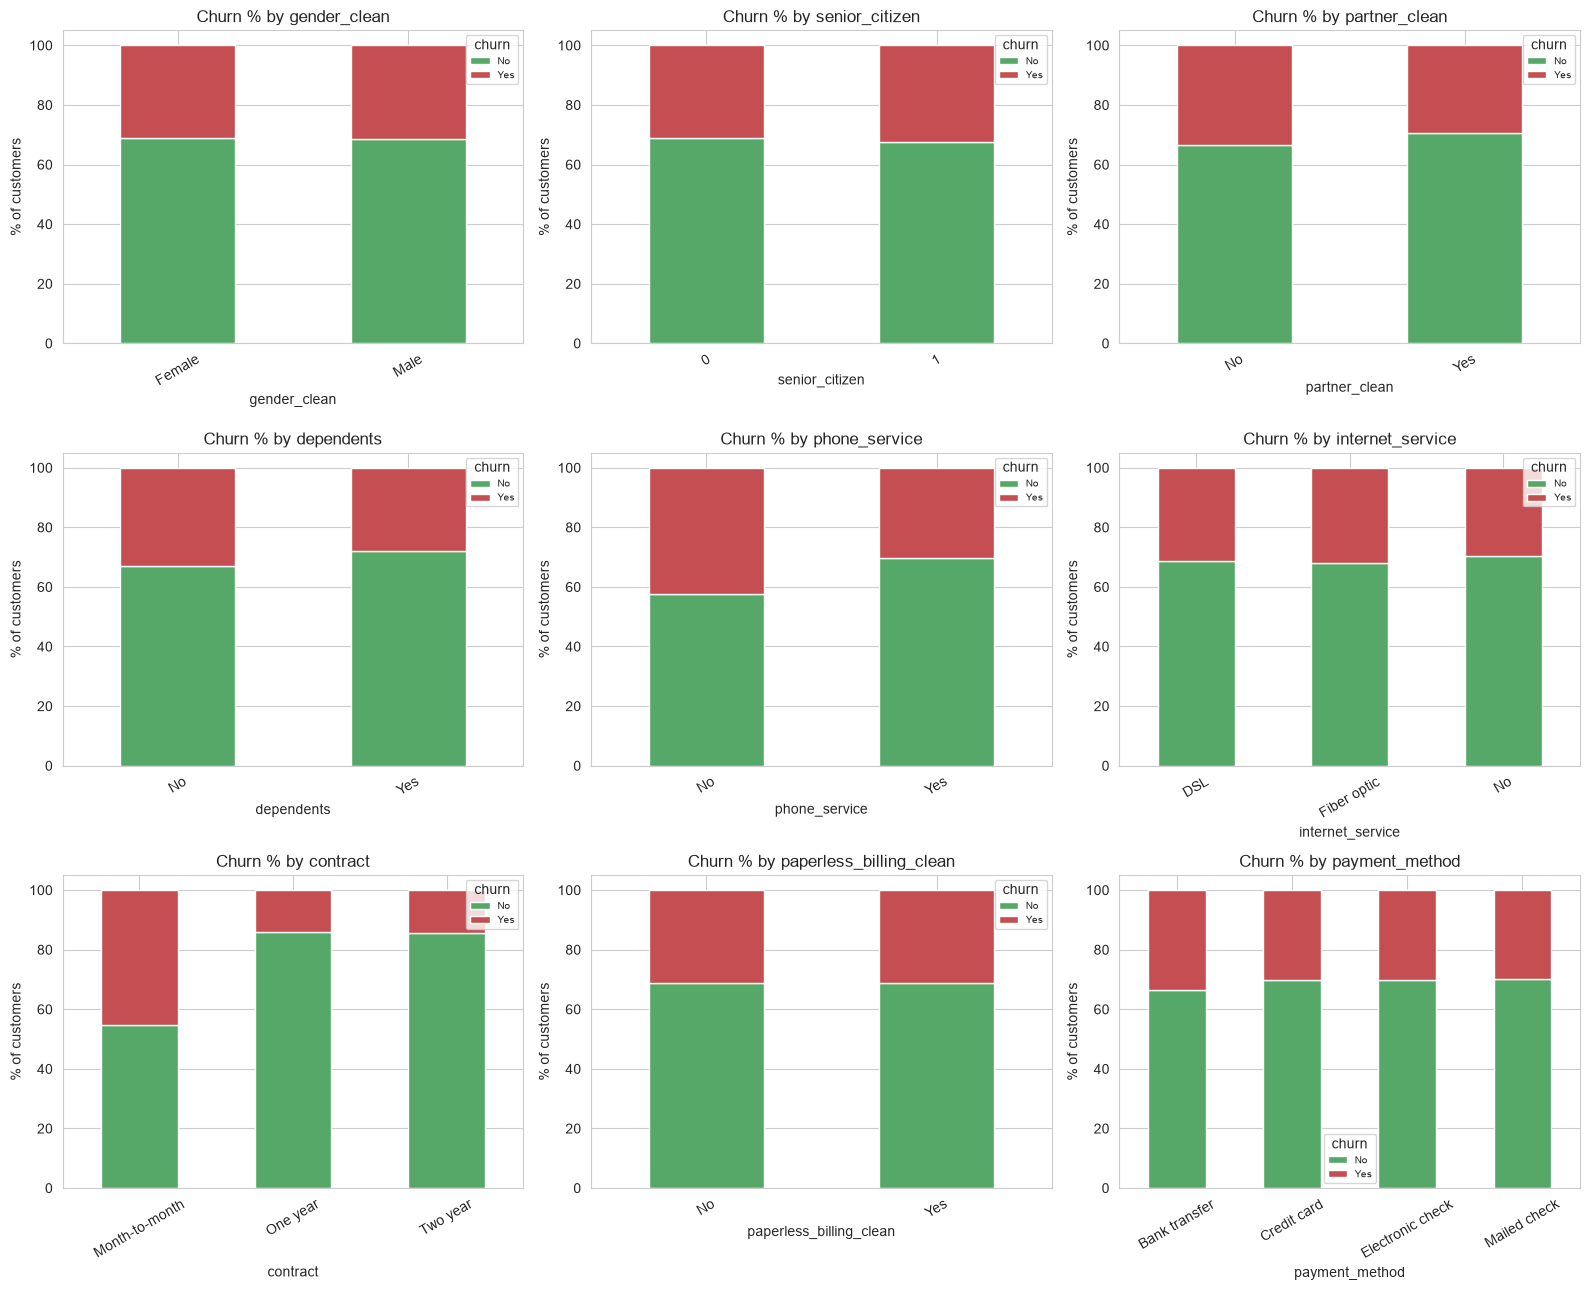

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for ax, col in zip(axes, clean_cat_cols):
    ct = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#55A868', '#C44E52'])
    ax.set_title(f'Churn % by {col}')
    ax.set_ylabel('% of customers')
    ax.legend(title='churn', fontsize=7)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpreting the stacked bars:** each bar shows the churn rate *within* that category
(normalized to 100%), so we can directly compare churn propensity across categories regardless of
how many customers are in each group.

## 7. Deep Dive: The Strongest Relationships

We examine the top 3 features by p-value from the chi-square ranking above — note that not all of
them will necessarily be statistically significant; we call that out explicitly where relevant.

In [13]:
top_features = chi_df.head(3)['feature'].tolist()
for col in top_features:
    print(f'=== {col} vs churn ===')
    ct = pd.crosstab(df[col], df['churn'])
    ct_pct = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    print(ct)
    print(ct_pct.round(1))
    print()

=== contract vs churn ===
churn            No  Yes
contract                
Month-to-month  306  253
One year        214   35
Two year        177   30
churn             No   Yes
contract                  
Month-to-month  54.7  45.3
One year        85.9  14.1
Two year        85.5  14.5

=== phone_service vs churn ===
churn           No  Yes
phone_service          
No              57   42
Yes            640  276
churn            No   Yes
phone_service            
No             57.6  42.4
Yes            69.9  30.1

=== dependents vs churn ===
churn        No  Yes
dependents          
No          470  230
Yes         227   88
churn         No   Yes
dependents            
No          67.1  32.9
Yes         72.1  27.9



**Business interpretation, based on the actual chi-square results above:**

- **`contract`** is by far the **strongest relationship** with churn (very large chi-square
  statistic, p ≈ 0): month-to-month customers churn at a much higher rate than one-year or
  two-year contract holders, since they face no penalty for leaving at any time. This is the one
  categorical feature that clearly stands out as a churn driver.
- **`phone_service`** also shows a **statistically significant** association (p < 0.05), though the
  effect size (chi-square statistic) is much smaller than `contract` — worth including as a
  secondary predictor, but not a dominant one.
- Somewhat counter-intuitively, **`internet_service` and `payment_method` do *not* come out as
  statistically significant** in this dataset (p > 0.05 for both) — despite being commonly
  predictive of churn in telecom datasets generally, here they don't show a clear association.
  This is a useful, data-driven finding: it means assumptions from "typical" churn analyses don't
  automatically transfer to every dataset, and it's worth re-checking such relationships rather
  than assuming them.
- **`gender_clean`, `paperless_billing_clean`, `senior_citizen`, `partner_clean`, and `dependents`**
  all have high p-values — no meaningful association with churn detected here.

**Takeaway:** in *this* dataset, `contract` type is the standout categorical driver of churn, with
`phone_service` a distant second — the rest of the categorical variables tested don't show a
statistically significant relationship with the target.
